# Benchmark Multi-Modèles — Classification du Domaine Métier

**Projet de Fin d'Études — Gouvernance de données Oracle PeopleSoft**  
**2026 | pfe-data-ia**

> **v2 — Aligné sur le pipeline de production** (`business_domain_production.ipynb`)  
> Feature engineering, prétraitement et constantes **identiques** à `production_pipeline_latest.joblib`.

---

## Objectif

Ce notebook constitue le **benchmark complet** de la tâche de classification multi-classe : assigner automatiquement un domaine métier à chaque table/collection de données.

| Modèle | Statut | Famille |
|--------|--------|---------|
| LogisticRegression | Reproduit (baseline) | ML Linéaire |
| **LinearSVC + Platt** | **Champion production** | ML Linéaire |
| LightGBM | Reproduit | Gradient Boosting |
| Random Forest | Reproduit | Ensemble / Bagging |
| XGBoost | Reproduit | Gradient Boosting |
| MLPClassifier | Reproduit | Deep Learning |

### Alignement avec la production

| Aspect | Ancienne version (v1) | Cette version (v2) |
|--------|-----------------------|--------------------|
| Dataset | `v5_remapped.csv` (6 classes remappées) | Gold dataset v4 (consensus ≥ 0.7, 7 classes) |
| TF-IDF char | `char_wb` (3-5), 80k, pas de min_df | `char_wb` (3-5), **50k**, **min_df=3** |
| TF-IDF word | `word` (1-2), 50k, pas de stopwords | `word` (1-2), **80k**, **min_df=3**, **SQL stopwords** |
| Réduction dim. | TruncatedSVD (50/60 composantes) | **Aucune** (sparse direct) |
| Features engineered | Aucune | **Ratios, logs, indicateurs PS, comptages keywords** |
| Features sémantiques | Aucune | **38 labels sémantiques** depuis `column_value_semantics_text` |
| CAT_COLS | `source_system`, `asset_type` | + **`has_profile_data`** |
| Scaler | `StandardScaler()` (dense) | **`StandardScaler(with_mean=False)`** (sparse) |
| Prétraitement texte | Aucun | **`normalize_text()`** (lower, split sur séparateurs) |

**Classes cibles :** Finance & Contrôle · IT & Sécurité · RH · Achats & Fournisseurs · Supply Chain · Ventes & Clients · Other

In [42]:
import warnings
import json
import time
import re
from collections import Counter
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scipy
from scipy.sparse import hstack, csr_matrix
from scipy.stats import randint, uniform, loguniform

# Scikit-learn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, learning_curve,
    RandomizedSearchCV, train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, OneHotEncoder, label_binarize
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_curve, auc
)
import joblib

# Packages optionnels
try:
    import lightgbm as lgb
    HAS_LGBM = True
    print('\u2713 LightGBM disponible')
except ImportError:
    HAS_LGBM = False
    print('\u2717 LightGBM non disponible (pip install lightgbm)')

try:
    import xgboost as xgb
    HAS_XGB = True
    print('\u2713 XGBoost disponible')
except ImportError:
    HAS_XGB = False
    print('\u2717 XGBoost non disponible (pip install xgboost)')

sns.set_theme(style='whitegrid', palette='husl', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})
RANDOM_STATE = 42
CV_FOLDS = 5
print('\n\u2713 Imports OK')

✓ LightGBM disponible
✓ XGBoost disponible

✓ Imports OK


## 0.1 Constantes de production

Copie exacte de `business_domain_production.ipynb` — **ne pas modifier sans réentraîner le modèle**.

In [43]:
# ============================================================
# Constantes IDENTIQUES à business_domain_production.ipynb
# ============================================================
CONSENSUS_FLOOR = 0.7

TARGET     = 'business_domain'
LEAK_COLS  = [
    'business_domain_raw', 'business_domain_label', 'labeling_notes',
    'llm_votes_json', 'llm_consensus_score', 'llm_models_used',
    'llm_prompt_version', 'llm_status', 'confidence', 'reason',
]
ID_COLS = ['run_id', 'asset_id']
DROPPED_TEXT_COLS = [
    'column_type_signature_text', 'column_value_semantics_text',
    'column_sample_values_text', 'column_observed_pattern_text',
]

TEXT_COLS_CHAR = ['technical_name', 'source_ref']
TEXT_COLS_WORD = ['column_names_text']
NUM_COLS = [
    'field_count', 'nullable_field_count', 'non_nullable_field_count',
    'numeric_field_count', 'date_field_count', 'text_field_count',
    'large_text_field_count', 'avg_data_length', 'max_data_length',
    'row_count', 'size_bytes', 'size_mb',
]
CAT_COLS = ['source_system', 'asset_type', 'has_profile_data']

CHAR_MAX_FEATURES = 50_000
WORD_MAX_FEATURES = 80_000
CHAR_NGRAMS = (3, 5)
WORD_NGRAMS = (1, 2)

SQL_STOPWORDS = [
    'varchar2', 'number', 'date', 'timestamp', 'clob', 'blob', 'long',
    'char', 'raw', 'xmltype', 'float', 'integer', 'nvarchar2', 'nclob',
    'timestamp(6)', 'sysadm', 'ps',
]

KNOWN_SEMANTIC_LABELS = [
    'label', 'quantity', 'identifier', 'financial_amount', 'classification',
    'date_or_timestamp', 'processing_identifier', 'status',
    'reference_identifier', 'percentage_or_rate', 'user_identifier',
    'technical_timestamp', 'flag', 'date_part', 'comment_text',
    'person_identifier', 'job_label', 'postal_location', 'email_address',
    'phone_number', 'url', 'score', 'duration', 'technical_identifier',
    'person_full_name', 'person_first_name', 'person_last_name',
    'file_reference', 'other', 'geo_longitude', 'geo_latitude',
]

DOMAIN_KEYWORDS = {
    'finance': [
        'invoice', 'payment', 'ledger', 'gl', 'tax', 'budget', 'amount',
        'cost', 'expense', 'revenue', 'accounting', 'journal', 'account',
        'ap', 'ar', 'fi', 'glacct', 'treasur', 'asset', 'deprec',
        'facture', 'paiement', 'comptabil', 'compte', 'montant', 'devise',
        'currency', 'vat', 'tva',
    ],
    'hr': [
        'employee', 'empl', 'emplid', 'job', 'manager', 'payroll', 'absence',
        'position', 'hire', 'worker', 'salary', 'person', 'headcount',
        'compensation', 'benefit', 'pay', 'leave', 'employe', 'salaire',
        'poste', 'conge',
    ],
    'it': [
        'user', 'role', 'access', 'auth', 'permission', 'config', 'server',
        'system', 'login', 'application', 'security', 'sysadm',
        'menu', 'page', 'xlat', 'dbowner', 'portal', 'prcs', 'audit',
    ],
    'procurement': [
        'vendor', 'supplier', 'purchase', 'po_', 'item', 'stock', 'inventory',
        'material', 'order', 'sourcing', 'rfq', 'contract',
        'fournisseur', 'achat', 'commande',
    ],
    'sales': [
        'customer', 'client', 'opportunity', 'quote', 'deal', 'crm',
        'sales', 'pipeline', 'booking', 'cust_', 'cust',
        'vente', 'facturation',
    ],
    'marketing': [
        'campaign', 'lead', 'segment', 'channel', 'audience', 'click',
        'impression', 'conversion', 'promo',
    ],
    'risk': [
        'risk', 'control', 'incident', 'compliance', 'issue',
        'mitigation', 'policy', 'controle', 'conformite',
    ],
    'supply_chain': [
        'shipment', 'warehouse', 'delivery', 'route',
        'transport', 'plant', 'logistics', 'bom', 'prod_',
        'livraison', 'entrepot', 'logistique', 'production',
    ],
}

PS_MODULE_PREFIXES = {
    'GL': 'finance', 'AP': 'finance', 'AR': 'finance', 'AM': 'finance',
    'BI': 'finance', 'TR': 'finance', 'EX': 'finance',
    'HR': 'hr',       'JOB': 'hr',    'PERSON': 'hr', 'BEN': 'hr',
    'PAY': 'hr',      'ABS': 'hr',    'COMP': 'hr',
    'PO': 'procurement', 'EP': 'procurement', 'RFQ': 'procurement',
    'CON': 'procurement', 'VND': 'procurement',
    'IN': 'supply_chain', 'PL': 'supply_chain', 'SF': 'supply_chain',
    'MG': 'supply_chain', 'PROD': 'supply_chain',
    'SA': 'sales', 'OM': 'sales', 'CRM': 'sales',
    'PRCS': 'it', 'PSAUTH': 'it', 'PSOPR': 'it',
    'PSROLE': 'it', 'PT': 'it', 'PSMENU': 'it',
}

print('\u2713 Constantes de production charg\u00e9es')
print(f'  Char TF-IDF : analyzer=char_wb, ngrams={CHAR_NGRAMS}, max_feat={CHAR_MAX_FEATURES:,}, min_df=3')
print(f'  Word TF-IDF : analyzer=word,    ngrams={WORD_NGRAMS}, max_feat={WORD_MAX_FEATURES:,}, min_df=3, SQL stopwords')
print(f'  NUM_COLS    : {len(NUM_COLS)} colonnes brutes')
print(f'  CAT_COLS    : {CAT_COLS}')
print(f'  Features eng. : ratios/logs/indicateurs PS ({len(PS_MODULE_PREFIXES)} modules) / keywords ({len(DOMAIN_KEYWORDS)} domaines)')
print(f'  Features sem. : {len(KNOWN_SEMANTIC_LABELS)} labels + 7 ratios = {len(KNOWN_SEMANTIC_LABELS)+7} colonnes')

✓ Constantes de production chargées
  Char TF-IDF : analyzer=char_wb, ngrams=(3, 5), max_feat=50,000, min_df=3
  Word TF-IDF : analyzer=word,    ngrams=(1, 2), max_feat=80,000, min_df=3, SQL stopwords
  NUM_COLS    : 12 colonnes brutes
  CAT_COLS    : ['source_system', 'asset_type', 'has_profile_data']
  Features eng. : ratios/logs/indicateurs PS (33 modules) / keywords (8 domaines)
  Features sem. : 31 labels + 7 ratios = 38 colonnes


## 0.2 Fonctions de production

Copie exacte de `business_domain_production.ipynb` — prétraitement, features engineered, features sémantiques.

In [44]:
# ============================================================
# Fonctions IDENTIQUES à business_domain_production.ipynb
# ============================================================

def normalize_text(x):
    if pd.isna(x):
        return ''
    x = str(x).lower()
    for sep in ['_', '-', '|', '/', '\\', '.', ':', ';', ',', '(', ')', '[', ']', '{', '}']:
        x = x.replace(sep, ' ')
    x = re.sub(r'[^a-z0-9\s]', ' ', x)
    return re.sub(r'\s+', ' ', x).strip()


def safe_div(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    return np.divide(a, b, out=np.zeros_like(a), where=b != 0)


def extract_prefix(tname):
    if not isinstance(tname, str):
        return ''
    s = re.sub(r'^[A-Z]+\.', '', tname.upper())
    s = re.sub(r'^PS[_]?', '', s)
    m = re.match(r'([A-Z]+)_', s)
    return m.group(1) if m else s.split('_')[0][:6]


def extract_semantic_profile(semantics_text):
    counts = Counter()
    if pd.isna(semantics_text) or str(semantics_text).strip() == '':
        return counts
    for pair in str(semantics_text).split('|'):
        pair = pair.strip()
        if ':' in pair:
            _, label = pair.split(':', 1)
            counts[label.strip().lower()] += 1
    return counts


def build_semantic_features(df):
    profiles = df['column_value_semantics_text'].apply(extract_semantic_profile)
    sem = pd.DataFrame(index=df.index)
    for label in KNOWN_SEMANTIC_LABELS:
        sem[f'sem_{label}'] = profiles.apply(lambda c: c.get(label, 0)).astype(np.int16)
    total = sem.sum(axis=1).replace(0, 1).astype(np.float32)
    for label in ['financial_amount', 'person_identifier', 'user_identifier',
                  'quantity', 'processing_identifier', 'flag', 'status']:
        col = f'sem_{label}'
        if col in sem.columns:
            sem[f'ratio_{label}'] = (sem[col] / total).astype(np.float32)
    return sem


def build_engineered_features(df):
    out = pd.DataFrame(index=df.index)
    fc = (
        df['field_count'].fillna(0).astype(np.float32).values
        if 'field_count' in df.columns
        else np.ones(len(df), dtype=np.float32)
    )
    for col, name in [
        ('numeric_field_count',    'ratio_numeric'),
        ('date_field_count',       'ratio_date'),
        ('text_field_count',       'ratio_text'),
        ('large_text_field_count', 'ratio_large_text'),
        ('nullable_field_count',   'ratio_nullable'),
        ('non_nullable_field_count', 'ratio_non_nullable'),
    ]:
        vals = (
            df[col].fillna(0).astype(np.float32).values
            if col in df.columns
            else np.zeros(len(df), dtype=np.float32)
        )
        out[name] = safe_div(vals, fc)
    for c in ['row_count', 'size_bytes', 'size_mb', 'avg_data_length', 'max_data_length']:
        vals = (
            df[c].fillna(0).astype(np.float32).values
            if c in df.columns
            else np.zeros(len(df), dtype=np.float32)
        )
        out[f'log_{c}'] = np.log1p(vals)
    out['avg_size_per_field'] = safe_div(
        df['size_bytes'].fillna(0).astype(np.float32).values if 'size_bytes' in df.columns else np.zeros(len(df)),
        np.maximum(fc, 1)
    )
    for prefix_col in TEXT_COLS_CHAR:
        s = (
            df[prefix_col].fillna('').astype(str)
            if prefix_col in df.columns
            else pd.Series([''] * len(df), index=df.index)
        )
        out[f'{prefix_col}_len']              = s.str.len().astype(np.int32)
        out[f'{prefix_col}_token_count']      = s.str.count(r'[A-Za-z0-9]+').astype(np.int32)
        out[f'{prefix_col}_digit_count']      = s.str.count(r'\d').astype(np.int32)
        out[f'{prefix_col}_underscore_count'] = s.str.count(r'_').astype(np.int32)
        total_len = s.str.len().replace(0, 1)
        out[f'{prefix_col}_upper_ratio']      = (s.str.count(r'[A-Z]') / total_len).astype(np.float32)
        out[f'{prefix_col}_has_id']           = s.str.contains(r'id',         case=False).astype(np.int8)
        out[f'{prefix_col}_has_dt']           = s.str.contains(r'dt|date',    case=False).astype(np.int8)
        out[f'{prefix_col}_has_amt']          = s.str.contains(r'amt|amount', case=False).astype(np.int8)
        out[f'{prefix_col}_has_cd']           = s.str.contains(r'cd|code',    case=False).astype(np.int8)
    if 'technical_name' in df.columns:
        prefixes = df['technical_name'].apply(extract_prefix)
        for mod in sorted(PS_MODULE_PREFIXES.keys()):
            out[f'ps_is_{mod}'] = (prefixes == mod).astype(np.int8)
    combined = (
        df.get('technical_name', pd.Series([''] * len(df), index=df.index)).fillna('').astype(str) + ' ' +
        df.get('source_ref',     pd.Series([''] * len(df), index=df.index)).fillna('').astype(str) + ' ' +
        df.get('column_names_text', pd.Series([''] * len(df), index=df.index)).fillna('').astype(str)
    ).str.lower()
    for domain, keywords in DOMAIN_KEYWORDS.items():
        pattern = r'\b(' + '|'.join(re.escape(k) for k in keywords) + r')\b'
        c_count = combined.str.count(pattern).astype(np.int16)
        out[f'{domain}_keyword_count'] = c_count
        out[f'has_{domain}_keyword']   = (c_count > 0).astype(np.int8)
    return out.fillna(0)


def prepare_dataframe(df):
    df = df.copy()
    for col in TEXT_COLS_CHAR + TEXT_COLS_WORD:
        if col in df.columns:
            df[col] = df[col].apply(normalize_text)
    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna('missing')
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0).astype(np.float32)
    return df


print('\u2713 Fonctions de production charg\u00e9es')
_n_eng = 6 + 5 + 1 + 9 * len(TEXT_COLS_CHAR) + len(PS_MODULE_PREFIXES) + len(DOMAIN_KEYWORDS) * 2
_n_sem = len(KNOWN_SEMANTIC_LABELS) + 7
print(f'  build_engineered_features : ~{_n_eng} features')
print(f'  build_semantic_features   : {_n_sem} features')
print(f'  Total num+eng+sem         : {len(NUM_COLS)} + {_n_eng} + {_n_sem} = {len(NUM_COLS)+_n_eng+_n_sem} features num\u00e9riques')

✓ Fonctions de production chargées
  build_engineered_features : ~79 features
  build_semantic_features   : 38 features
  Total num+eng+sem         : 12 + 79 + 38 = 129 features numériques


## 0.3 `ProductionPreprocessor` — Transformateur sklearn

Encapsule **tout le pipeline de features de production** dans un `BaseEstimator` compatible `cross_validate`.  
Entrée : DataFrame brut · Sortie : matrice sparse CSR (même structure que `production_pipeline_latest.joblib`).

In [45]:
class ProductionPreprocessor(BaseEstimator, TransformerMixin):
    """Pipeline de features identique à la production.

    Étapes :
    1. Semantic features (column_value_semantics_text) AVANT drop
    2. Drop LEAK_COLS + ID_COLS + DROPPED_TEXT_COLS
    3. prepare_dataframe (normalize_text, cat→str, num→float32)
    4. TF-IDF char_wb (3-5 grams, 50k, min_df=3)
    5. TF-IDF word (1-2 grams, 80k, min_df=3, SQL stopwords)
    6. build_engineered_features
    7. concat(NUM_COLS + engineered + semantic) → StandardScaler(with_mean=False)
    8. OHE(source_system, asset_type, has_profile_data)
    9. hstack → CSR
    """

    def _empty_sem(self, n):
        cols = (
            [f'sem_{l}' for l in KNOWN_SEMANTIC_LABELS] +
            [f'ratio_{l}' for l in ['financial_amount', 'person_identifier',
                                     'user_identifier', 'quantity',
                                     'processing_identifier', 'flag', 'status']]
        )
        return pd.DataFrame(0.0, index=range(n), columns=cols)

    def fit(self, X, y=None):
        X = X.reset_index(drop=True)

        # 1. Semantic AVANT drop
        sem = (
            build_semantic_features(X)
            if 'column_value_semantics_text' in X.columns
            else self._empty_sem(len(X))
        )
        self._sem_cols = list(sem.columns)

        # 2. Drop fuites + textes bruts
        to_drop = [c for c in LEAK_COLS + ID_COLS + DROPPED_TEXT_COLS if c in X.columns]
        X_p = prepare_dataframe(X.drop(columns=to_drop))

        # 3. TF-IDF
        char_text = X_p[TEXT_COLS_CHAR].fillna('').astype(str).agg(' '.join, axis=1)
        word_text = X_p[TEXT_COLS_WORD].fillna('').astype(str).agg(' '.join, axis=1)
        self.char_vec_ = TfidfVectorizer(
            analyzer='char_wb', ngram_range=CHAR_NGRAMS,
            max_features=CHAR_MAX_FEATURES, min_df=3,
            sublinear_tf=True, dtype=np.float32,
        )
        self.word_vec_ = TfidfVectorizer(
            analyzer='word', ngram_range=WORD_NGRAMS,
            max_features=WORD_MAX_FEATURES, min_df=3,
            sublinear_tf=True, dtype=np.float32,
            stop_words=SQL_STOPWORDS,
        )
        self.char_vec_.fit(char_text)
        self.word_vec_.fit(word_text)

        # 4. Numeric + engineered + semantic
        eng = build_engineered_features(X_p)
        num_df = pd.concat([
            X_p[[c for c in NUM_COLS if c in X_p.columns]].astype(np.float32).reset_index(drop=True),
            eng.reset_index(drop=True),
            sem.reset_index(drop=True),
        ], axis=1)
        self._num_cols = list(num_df.columns)
        self.num_scaler_ = StandardScaler(with_mean=False)
        self.num_scaler_.fit(num_df.values.astype(np.float32))

        # 5. OHE
        cat_present = [c for c in CAT_COLS if c in X_p.columns]
        self._cat_cols = cat_present
        try:
            self.ohe_ = OneHotEncoder(handle_unknown='ignore', sparse_output=True, dtype=np.float32)
        except TypeError:
            self.ohe_ = OneHotEncoder(handle_unknown='ignore', sparse=True, dtype=np.float32)
        self.ohe_.fit(X_p[cat_present].astype(str))
        return self

    def transform(self, X):
        X = X.reset_index(drop=True)
        sem = (
            build_semantic_features(X)
            if 'column_value_semantics_text' in X.columns
            else pd.DataFrame(0.0, index=range(len(X)), columns=self._sem_cols)
        )
        to_drop = [c for c in LEAK_COLS + ID_COLS + DROPPED_TEXT_COLS if c in X.columns]
        X_p = prepare_dataframe(X.drop(columns=to_drop))
        char_text = X_p[TEXT_COLS_CHAR].fillna('').astype(str).agg(' '.join, axis=1)
        word_text = X_p[TEXT_COLS_WORD].fillna('').astype(str).agg(' '.join, axis=1)
        X_char = self.char_vec_.transform(char_text)
        X_word = self.word_vec_.transform(word_text)
        eng = build_engineered_features(X_p)
        num_df = pd.concat([
            X_p[[c for c in NUM_COLS if c in X_p.columns]].astype(np.float32).reset_index(drop=True),
            eng.reset_index(drop=True),
            sem.reset_index(drop=True),
        ], axis=1)
        for col in self._num_cols:
            if col not in num_df.columns:
                num_df[col] = 0.0
        num_df = num_df[self._num_cols]
        X_num = csr_matrix(self.num_scaler_.transform(num_df.values.astype(np.float32)))
        X_cat = self.ohe_.transform(X_p[[c for c in self._cat_cols if c in X_p.columns]].astype(str))
        return hstack([X_char, X_word, X_num, X_cat]).tocsr()


def build_pipeline(clf):
    """Enveloppe un classificateur dans le pipeline de production complet."""
    return Pipeline([
        ('preprocessor', ProductionPreprocessor()),
        ('classifier',   clf),
    ])


print('\u2713 ProductionPreprocessor d\u00e9fini')
print('  Pipeline sparse : TF-IDF char_wb \u2192 TF-IDF word \u2192 Num+Eng+Sem (StandardScaler) \u2192 OHE \u2192 hstack \u2192 clf')

✓ ProductionPreprocessor défini
  Pipeline sparse : TF-IDF char_wb → TF-IDF word → Num+Eng+Sem (StandardScaler) → OHE → hstack → clf


---
## 1. Chargement et préparation des données

Priorité au **gold dataset v4** (même fichier que la production, filtré consensus ≥ 0.7).  
Fallback automatique sur les datasets alternatifs si le fichier principal est absent.

In [46]:
BASE_DIR = Path('../')

DATASET_PATHS = [
    BASE_DIR / 'exports/dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_business_domain_v4.csv',
    BASE_DIR / 'exports/dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_annotated.csv',
    BASE_DIR / 'exports/dataset_asset_ml_training_v5_remapped.csv',
    BASE_DIR / 'artifacts/labeled_dataset_clean.csv',
]


def detect_encoding(path):
    for enc in ('utf-8', 'utf-8-sig', 'latin-1', 'cp1252'):
        try:
            with open(path, 'r', encoding=enc) as f:
                f.read(4096)
            return enc
        except UnicodeDecodeError:
            continue
    return 'latin-1'


df_raw = None
for path in DATASET_PATHS:
    if path.exists():
        enc = detect_encoding(path)
        with open(path, 'r', encoding=enc) as f:
            first_line = f.readline()
        sep = ';' if first_line.count(';') > first_line.count(',') else ','
        df_raw = pd.read_csv(path, sep=sep, encoding=enc, low_memory=False)
        print(f'\u2713 Dataset charg\u00e9 : {path.name}')
        print(f'  Encodage: \'{enc}\'  |  S\u00e9parateur: \'{sep}\'  |  Shape: {df_raw.shape}')
        break

if df_raw is None:
    raise FileNotFoundError('Aucun dataset trouv\u00e9 ! V\u00e9rifier les chemins DATASET_PATHS.')

# --- Filtrage qualité gold ---
n_raw = len(df_raw)
if 'llm_consensus_score' in df_raw.columns:
    df_raw['llm_consensus_score'] = pd.to_numeric(df_raw['llm_consensus_score'], errors='coerce')
    df_data = df_raw[df_raw['llm_consensus_score'] >= CONSENSUS_FLOOR].copy()
    print(f'\n  Filtre gold (consensus \u2265 {CONSENSUS_FLOOR}) : {n_raw:,} \u2192 {len(df_data):,} lignes ({100*len(df_data)/n_raw:.1f}%)')
elif 'needs_review' in df_raw.columns:
    df_data = df_raw[~df_raw['needs_review'].isin([True, 'VRAI', 1, '1', 'true', 'True'])].copy()
    print(f'\n  Filtre needs_review : {n_raw:,} \u2192 {len(df_data):,} lignes')
else:
    df_data = df_raw.copy()
    print('\n  Aucun filtre qualit\u00e9 disponible \u2014 dataset complet utilis\u00e9')

# --- Vérification colonne cible ---
target_candidates = [TARGET, 'label_normalized', 'business_domain_label']
target_col = next((c for c in target_candidates if c in df_data.columns), None)
if target_col is None:
    print('Colonnes disponibles :', list(df_data.columns))
    raise ValueError('Colonne cible non trouv\u00e9e.')
if target_col != TARGET:
    df_data = df_data.rename(columns={target_col: TARGET})
    print(f'  Colonne cible renomm\u00e9e : {target_col!r} \u2192 {TARGET!r}')

df_data = df_data.dropna(subset=[TARGET])
df_data = df_data[df_data[TARGET].astype(str).str.strip() != ''].copy()
print(f'  Apr\u00e8s nettoyage : {len(df_data):,} lignes exploitables')

✓ Dataset chargé : dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_business_domain_v4.csv
  Encodage: 'utf-8'  |  Séparateur: ','  |  Shape: (20000, 33)

  Filtre gold (consensus ≥ 0.7) : 20,000 → 18,473 lignes (92.4%)
  Après nettoyage : 18,473 lignes exploitables


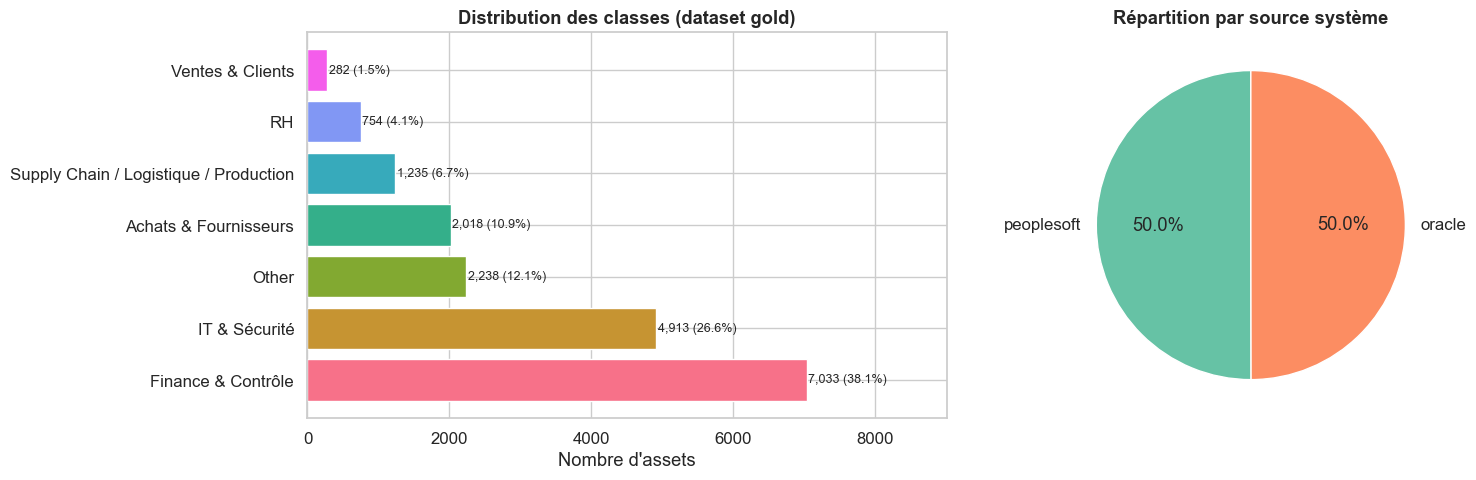


── Distribution des classes ──
  Finance & Contrôle                                     7033 (38.1%)
  IT & Sécurité                                          4913 (26.6%)
  Other                                                  2238 (12.1%)
  Achats & Fournisseurs                                  2018 (10.9%)
  Supply Chain / Logistique / Production                 1235 (6.7%)
  RH                                                      754 (4.1%)
  Ventes & Clients                                        282 (1.5%)

  Total : 18,473 assets, 7 classes
  Ratio déséquilibre : 24.9×


In [47]:
# ── Analyse exploratoire rapide ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dist = df_data[TARGET].value_counts()
colors = sns.color_palette('husl', len(dist))
bars = axes[0].barh(dist.index, dist.values, color=colors)
axes[0].set_xlabel("Nombre d'assets")
axes[0].set_title('Distribution des classes (dataset gold)', fontweight='bold')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{val:,} ({val / len(df_data) * 100:.1f}%)', va='center', fontsize=9)
axes[0].set_xlim(0, dist.max() * 1.28)

if 'source_system' in df_data.columns:
    src_dist = df_data['source_system'].value_counts()
    axes[1].pie(src_dist.values, labels=src_dist.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2', len(src_dist)), startangle=90)
    axes[1].set_title('R\u00e9partition par source syst\u00e8me', fontweight='bold')
else:
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('../artifacts/eda_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print('\n\u2500\u2500 Distribution des classes \u2500\u2500')
for label, count in dist.items():
    print(f'  {label:<52} {count:>6} ({count / len(df_data) * 100:.1f}%)')
print(f'\n  Total : {len(df_data):,} assets, {len(dist)} classes')
print(f'  Ratio d\u00e9s\u00e9quilibre : {dist.max() / dist.min():.1f}\u00d7')

## 2. Préparation de X et y

**X** = DataFrame brut complet (sans la colonne cible).  
Le `ProductionPreprocessor` sélectionne et transforme les colonnes pertinentes lors du `fit`.  
Dimension finale attendue : **~130k features** (50k char-TF-IDF + 80k word-TF-IDF + ~130 num/eng/sem/OHE).

In [48]:
le = LabelEncoder()
y  = le.fit_transform(df_data[TARGET].astype(str))
classes   = le.classes_
n_classes = len(classes)

# X = DataFrame complet (le ProductionPreprocessor gère le drop interne)
X = df_data.drop(columns=[TARGET]).copy()

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Classes encod\u00e9es ({n_classes}) :')
for i, c in enumerate(classes):
    n = int((y == i).sum())
    print(f'  {i}: {c:<52} ({n:>6} exemples, {100 * n / len(y):.1f}%)')
print(f'\nX_train : {X_train.shape}  |  X_test : {X_test.shape}')
print('\nLe ProductionPreprocessor construira ~130k features sparse par fold.')

Classes encodées (7) :
  0: Achats & Fournisseurs                                (  2018 exemples, 10.9%)
  1: Finance & Contrôle                                   (  7033 exemples, 38.1%)
  2: IT & Sécurité                                        (  4913 exemples, 26.6%)
  3: Other                                                (  2238 exemples, 12.1%)
  4: RH                                                   (   754 exemples, 4.1%)
  5: Supply Chain / Logistique / Production               (  1235 exemples, 6.7%)
  6: Ventes & Clients                                     (   282 exemples, 1.5%)

X_train : (14778, 32)  |  X_test : (3695, 32)

Le ProductionPreprocessor construira ~130k features sparse par fold.


---
## 3. Comparaison des modèles — Cross-validation 5 folds

Évaluation avec **StratifiedKFold(5)** — chaque fold utilise le `ProductionPreprocessor` complet  
(fit TF-IDF + scaler + OHE sur le train fold uniquement, **aucune fuite de données**).

> **Note :** `n_jobs=1` pour le CV — la parallélisation fold-par-fold avec un `TransformerMixin`  
> défini dans le notebook nécessite cloudpickle. Les classifieurs utilisent leur propre parallélisme.

In [49]:
MODELS = {
    'LogisticRegression': LogisticRegression(
        max_iter=2000, class_weight='balanced',
        solver='lbfgs', random_state=RANDOM_STATE
    ),
    'LinearSVC + Platt': CalibratedClassifierCV(
        LinearSVC(max_iter=4000, class_weight='balanced',
                  random_state=RANDOM_STATE, C=1.0),
        cv=3, method='sigmoid'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=2,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'MLP (Deep Learning)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu',
        solver='adam', alpha=1e-4, batch_size=256,
        max_iter=300, early_stopping=True, validation_fraction=0.1,
        random_state=RANDOM_STATE
    ),
}

if HAS_LGBM:
    MODELS['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )

if HAS_XGB:
    MODELS['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
    )

print(f'\u2713 {len(MODELS)} mod\u00e8les d\u00e9finis :')
for name in MODELS:
    print(f'  - {name}')

✓ 6 modèles définis :
  - LogisticRegression
  - LinearSVC + Platt
  - Random Forest
  - MLP (Deep Learning)
  - LightGBM
  - XGBoost


In [50]:
cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'}

cv_results = {}
print(f'Cross-validation {CV_FOLDS}-fold (pipeline de production) en cours...\n')
print(f'{"Mod\u00e8le":<28} {"Acc":>6}  {"F1-Macro":>8}  {"F1-Wgt":>8}  {"Temps":>7}')
print('-' * 68)

for name, clf in MODELS.items():
    pipe = build_pipeline(clf)
    t0   = time.time()
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv_splitter, scoring=SCORING,
        n_jobs=1, error_score='raise'
    )
    elapsed = time.time() - t0

    cv_results[name] = {
        'acc_mean':   scores['test_accuracy'].mean(),
        'acc_std':    scores['test_accuracy'].std(),
        'macro_mean': scores['test_f1_macro'].mean(),
        'macro_std':  scores['test_f1_macro'].std(),
        'wgt_mean':   scores['test_f1_weighted'].mean(),
        'wgt_std':    scores['test_f1_weighted'].std(),
        'time_s':     elapsed,
        'raw_scores': scores,
    }
    print(
        f'{name:<28} '
        f'{scores["test_accuracy"].mean():>6.4f}  '
        f'{scores["test_f1_macro"].mean():>8.4f}  '
        f'{scores["test_f1_weighted"].mean():>8.4f}  '
        f'{elapsed:>6.1f}s'
    )

print('\n\u2713 Cross-validation termin\u00e9e')

Cross-validation 5-fold (pipeline de production) en cours...

Modèle                          Acc  F1-Macro    F1-Wgt    Temps
--------------------------------------------------------------------
LogisticRegression           0.8710    0.8301    0.8743   413.1s
LinearSVC + Platt            0.9070    0.8691    0.9071   326.6s
Random Forest                0.8407    0.8049    0.8456   110.8s
MLP (Deep Learning)          0.8931    0.8533    0.8931  1250.0s
LightGBM                     0.9085    0.8671    0.9089  1019.6s
XGBoost                      0.8862    0.8452    0.8874  3470.9s

✓ Cross-validation terminée



── Résultats Cross-Validation (triés par Macro-F1) ──


,Modèle,Accuracy,Macro-F1,Weighted-F1,Temps (s)
1,LinearSVC + Platt,0.9070 ± 0.0042,0.8691 ± 0.0093,0.9071 ± 0.0042,326.6
2,LightGBM,0.9085 ± 0.0051,0.8671 ± 0.0107,0.9089 ± 0.0053,1019.6
3,MLP (Deep Learning),0.8931 ± 0.0070,0.8533 ± 0.0123,0.8931 ± 0.0070,1250.0
4,XGBoost,0.8862 ± 0.0048,0.8452 ± 0.0121,0.8874 ± 0.0050,3470.9
5,LogisticRegression,0.8710 ± 0.0044,0.8301 ± 0.0070,0.8743 ± 0.0043,413.1
6,Random Forest,0.8407 ± 0.0041,0.8049 ± 0.0089,0.8456 ± 0.0043,110.8



✓ Sauvégardé → artifacts/benchmark_cv_results.csv


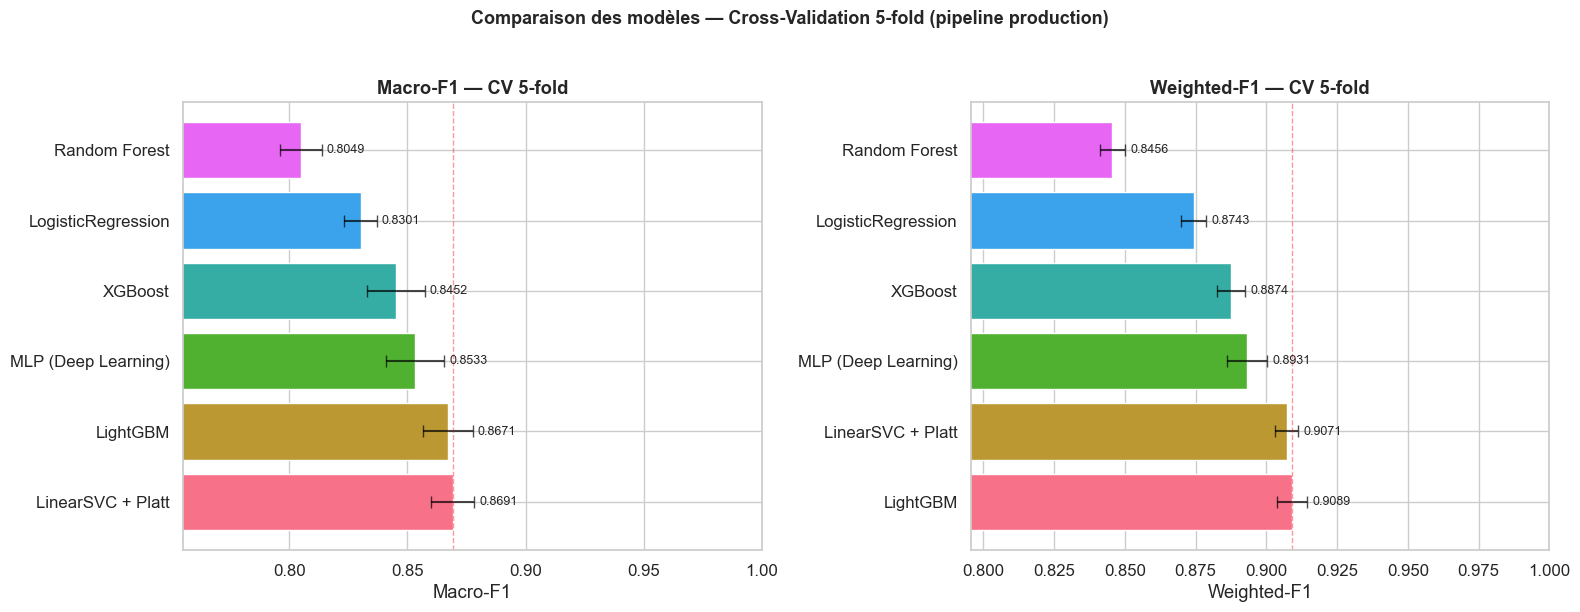

In [51]:
# ── Tableau de résultats ──
rows = []
for name, res in cv_results.items():
    rows.append({
        'Mod\u00e8le':      name,
        'Accuracy':    f"{res['acc_mean']:.4f} \u00b1 {res['acc_std']:.4f}",
        'Macro-F1':    f"{res['macro_mean']:.4f} \u00b1 {res['macro_std']:.4f}",
        'Weighted-F1': f"{res['wgt_mean']:.4f} \u00b1 {res['wgt_std']:.4f}",
        'Temps (s)':   f"{res['time_s']:.1f}",
        '_macro_val':  res['macro_mean'],
    })

df_cv = (
    pd.DataFrame(rows)
    .sort_values('_macro_val', ascending=False)
    .drop(columns='_macro_val')
    .reset_index(drop=True)
)
df_cv.index = range(1, len(df_cv) + 1)
print('\n\u2500\u2500 R\u00e9sultats Cross-Validation (tri\u00e9s par Macro-F1) \u2500\u2500')
display(df_cv)

df_cv.to_csv('../artifacts/benchmark_cv_results.csv', index=False)
print('\n\u2713 Sauv\u00e9gard\u00e9 \u2192 artifacts/benchmark_cv_results.csv')

# ── Graphique comparatif ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, col, label in [
    (axes[0], 'macro_mean', 'macro_std', 'Macro-F1'),
    (axes[1], 'wgt_mean',   'wgt_std',   'Weighted-F1'),
]:
    names  = list(cv_results.keys())
    means  = [cv_results[n][metric] for n in names]
    stds   = [cv_results[n][col]    for n in names]
    order  = np.argsort(means)[::-1]
    ns = [names[i] for i in order]
    ms = [means[i] for i in order]
    ss = [stds[i]  for i in order]
    palette = sns.color_palette('husl', len(ns))
    bars = ax.barh(ns, ms, xerr=ss, color=palette,
                   capsize=4, error_kw={'elinewidth': 1.5, 'alpha': 0.7})
    ax.set_xlabel(label)
    ax.set_title(f'{label} \u2014 CV {CV_FOLDS}-fold', fontweight='bold')
    ax.set_xlim(max(0, min(ms) - 0.05), 1.0)
    for bar, val, std in zip(bars, ms, ss):
        ax.text(val + std + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.axvline(x=ms[0], color='red', linestyle='--', alpha=0.4, linewidth=1)

plt.suptitle('Comparaison des mod\u00e8les \u2014 Cross-Validation 5-fold (pipeline production)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/benchmark_cv_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Matrices de confusion (holdout 20%)

In [52]:
fitted_models    = {}
test_predictions = {}

print('Entra\u00eenement final sur 80% du dataset (pipeline production)...')
for name, clf in MODELS.items():
    pipe = build_pipeline(clf)
    t0   = time.time()
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    y_pred = pipe.predict(X_test)
    test_predictions[name] = y_pred
    macro = f1_score(y_test, y_pred, average='macro')
    wgt   = f1_score(y_test, y_pred, average='weighted')
    acc   = accuracy_score(y_test, y_pred)
    print(f'  {name:<28}  Acc={acc:.4f}  Macro-F1={macro:.4f}  Weighted-F1={wgt:.4f}  ({time.time()-t0:.1f}s)')

print('\n\u2713 Entra\u00eenement termin\u00e9')

Entraînement final sur 80% du dataset (pipeline production)...
  LogisticRegression            Acc=0.8880  Macro-F1=0.8567  Weighted-F1=0.8909  (116.9s)
  LinearSVC + Platt             Acc=0.9150  Macro-F1=0.8846  Weighted-F1=0.9151  (99.2s)
  Random Forest                 Acc=0.8479  Macro-F1=0.8102  Weighted-F1=0.8525  (30.7s)
  MLP (Deep Learning)           Acc=0.9064  Macro-F1=0.8793  Weighted-F1=0.9065  (815.6s)
  LightGBM                      Acc=0.9223  Macro-F1=0.8854  Weighted-F1=0.9230  (32853.1s)
  XGBoost                       Acc=0.8969  Macro-F1=0.8614  Weighted-F1=0.8981  (789.3s)

✓ Entraînement terminé


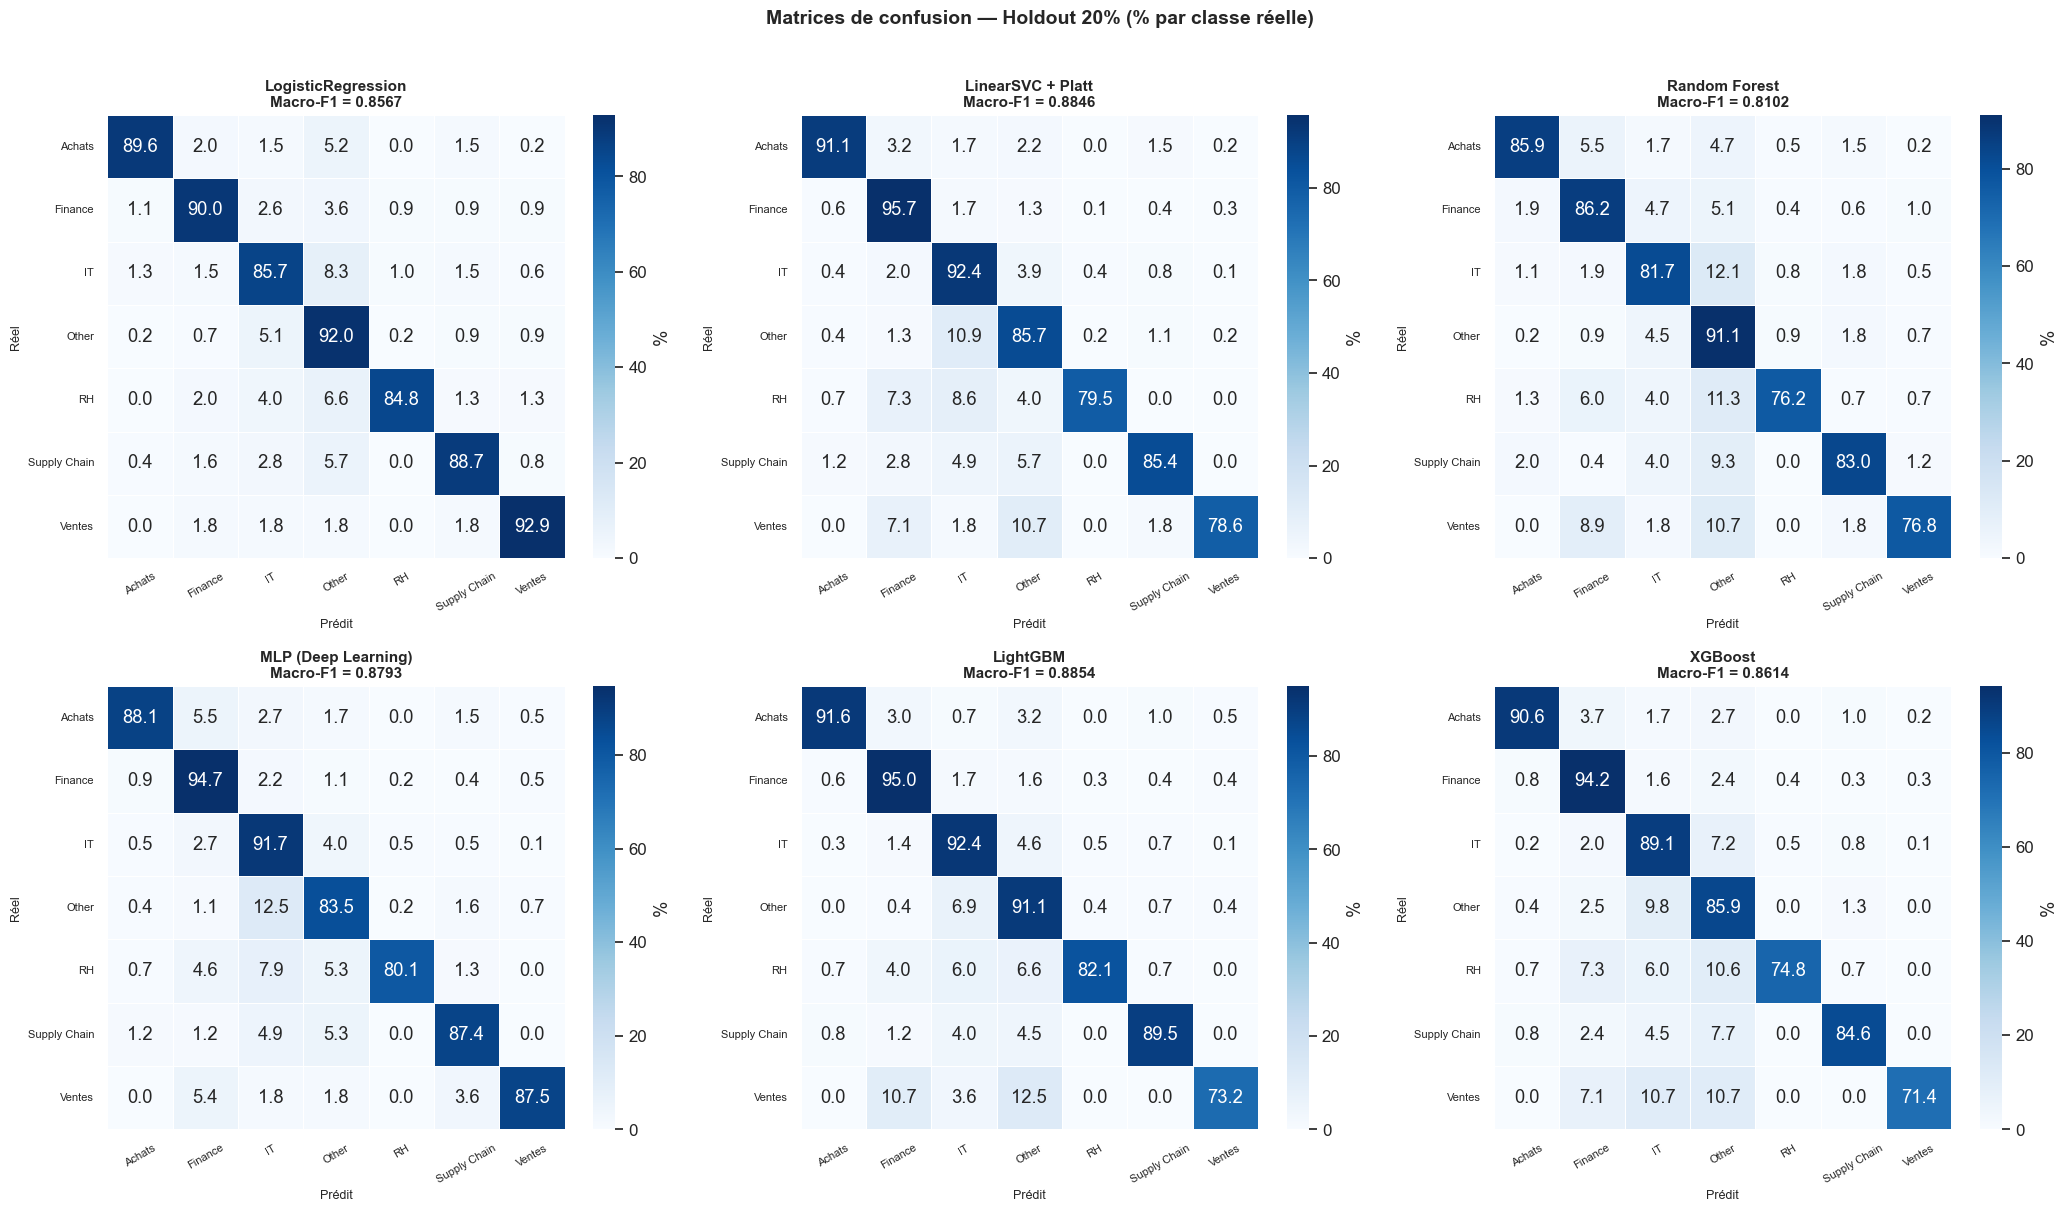

In [53]:
# ── Matrices de confusion ──
n_models = len(fitted_models)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes_flat = axes.flatten() if n_models > 1 else [axes]

# Labels courts
short_labels = [
    c.replace('Finance & Contr\u00f4le', 'Finance')
     .replace('IT & S\u00e9curit\u00e9', 'IT')
     .replace('Achats & Fournisseurs', 'Achats')
     .replace('Supply Chain / Logistique / Production', 'Supply Chain')
     .replace('Ventes & Clients', 'Ventes')
    for c in classes
]

for ax, (name, y_pred) in zip(axes_flat, test_predictions.items()):
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, cbar_kws={'label': '%'}, linewidths=0.5
    )
    macro = f1_score(y_test, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro-F1 = {macro:.4f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Pr\u00e9dit', fontsize=9)
    ax.set_ylabel('R\u00e9el', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.suptitle('Matrices de confusion \u2014 Holdout 20% (% par classe r\u00e9elle)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../artifacts/benchmark_confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Courbes ROC — One-vs-Rest (AUC par classe)

La courbe ROC mesure la capacité du modèle à discriminer chaque classe contre toutes les autres.  
L'**AUC** proche de **1.0** indique une discrimination parfaite.

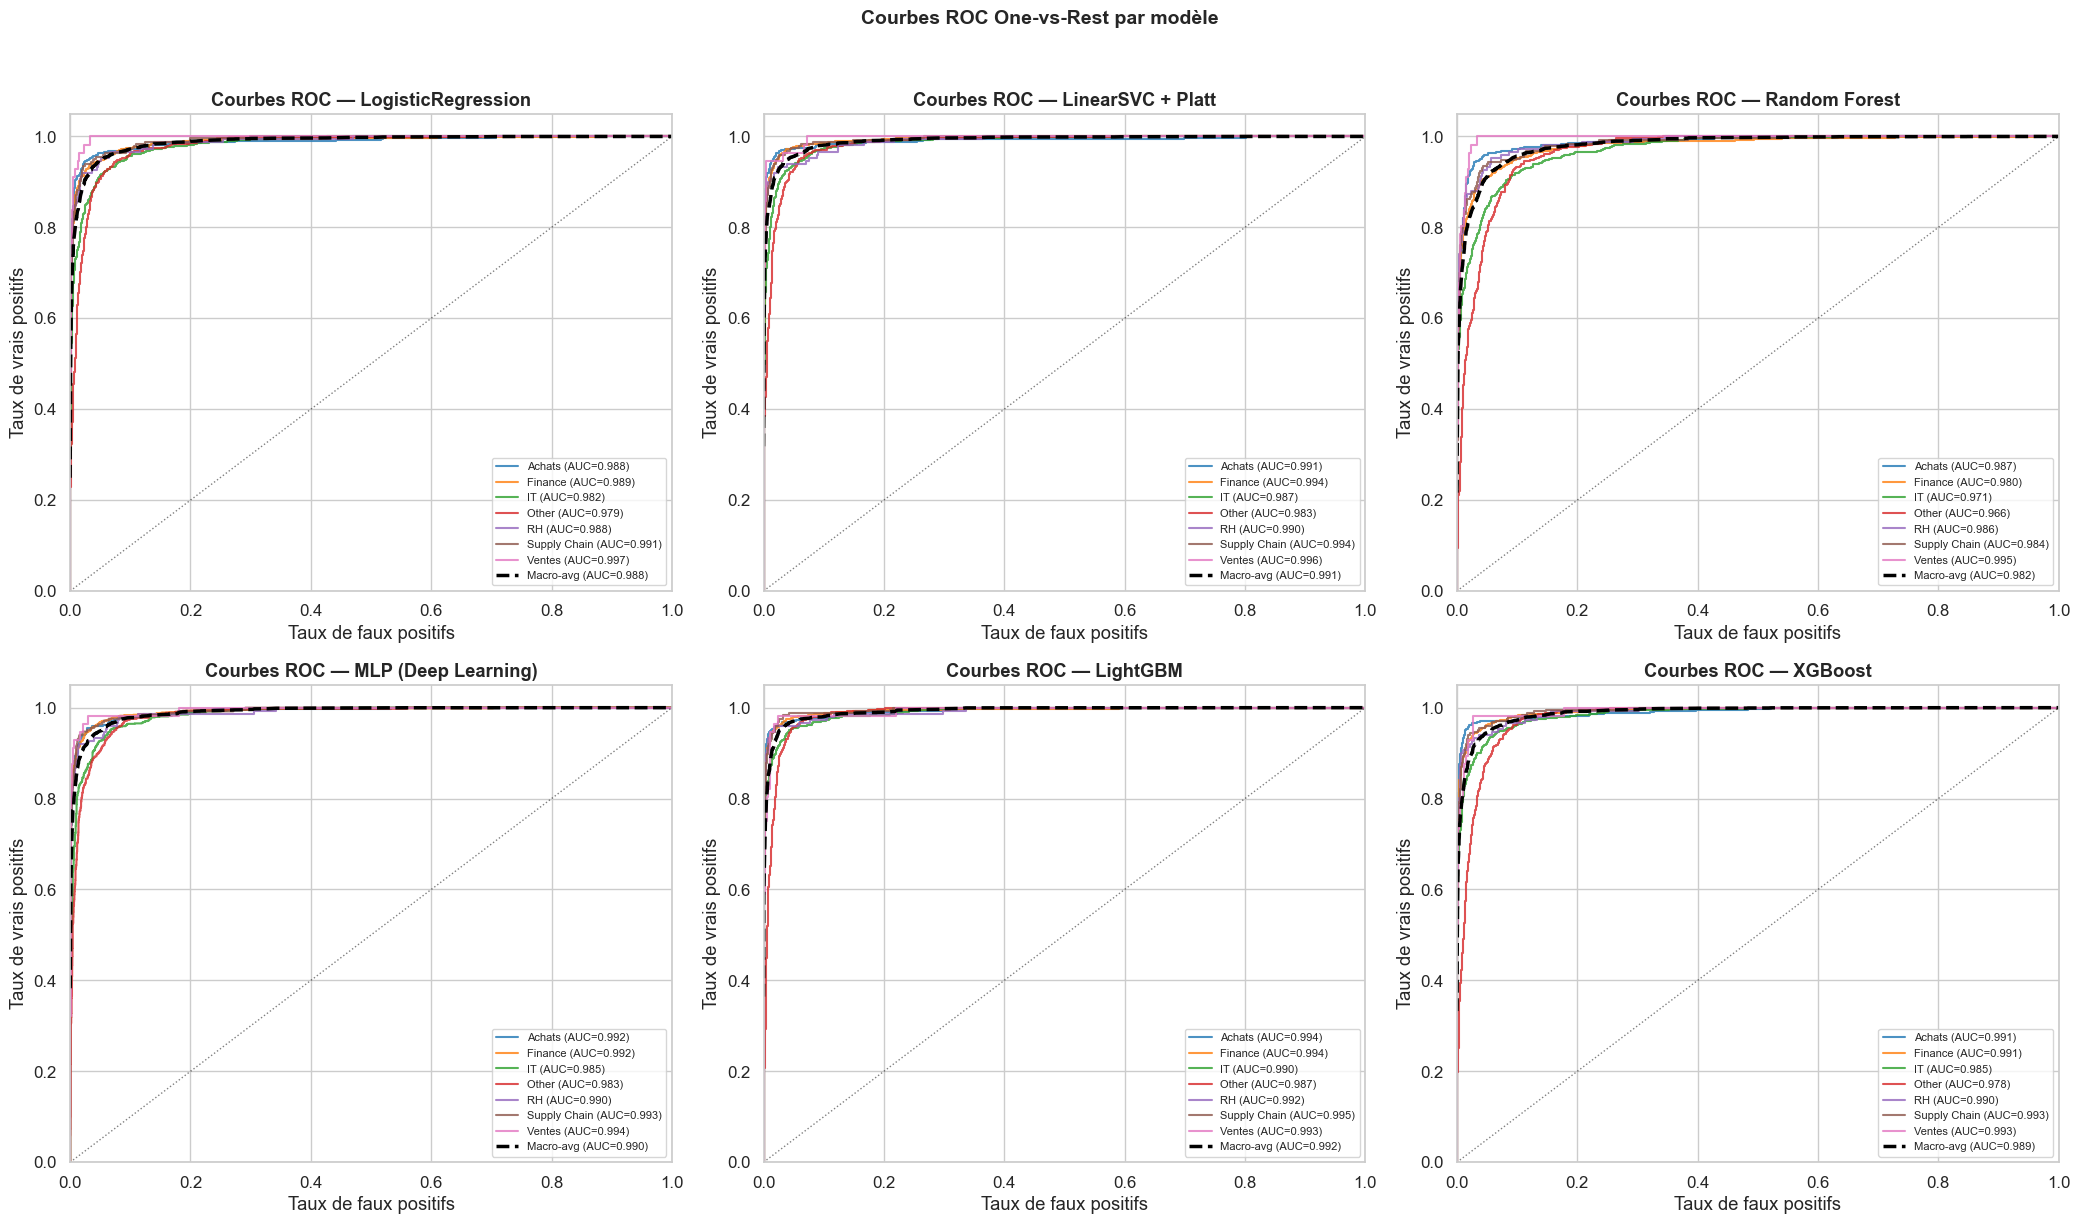

In [54]:
roc_models = {name: pipe for name, pipe in fitted_models.items()
              if hasattr(pipe, 'predict_proba')}

if not roc_models:
    print('Aucun mod\u00e8le avec predict_proba disponible.')
else:
    y_test_bin   = label_binarize(y_test, classes=list(range(n_classes)))
    short_labels_dict = dict(zip(range(n_classes), short_labels))
    colors_roc   = sns.color_palette('tab10', n_classes)

    n_cols = min(3, len(roc_models))
    n_rows = (len(roc_models) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    if len(roc_models) == 1:
        axes = np.array([[axes]])
    axes_flat = axes.flatten()

    for ax, (name, pipe) in zip(axes_flat, roc_models.items()):
        y_proba = pipe.predict_proba(X_test)
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors_roc[i], lw=1.5, alpha=0.8,
                    label=f'{short_labels_dict[i]} (AUC={roc_auc:.3f})')

        all_fpr  = np.unique(np.concatenate([
            roc_curve(y_test_bin[:, i], y_proba[:, i])[0] for i in range(n_classes)
        ]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)

        ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
                label=f'Macro-avg (AUC={macro_auc:.3f})')
        ax.plot([0, 1], [0, 1], 'k:', lw=1, alpha=0.5)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('Taux de faux positifs')
        ax.set_ylabel('Taux de vrais positifs')
        ax.set_title(f'Courbes ROC \u2014 {name}', fontweight='bold')
        ax.legend(loc='lower right', fontsize=8)

    for ax in axes_flat[len(roc_models):]:
        ax.set_visible(False)

    plt.suptitle('Courbes ROC One-vs-Rest par mod\u00e8le', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../artifacts/benchmark_roc_curves.png', dpi=100, bbox_inches='tight')
    plt.show()

## 6. Courbes d'apprentissage

- **Gap train–validation large** → sur-apprentissage
- **Gap faible + scores bas** → sous-apprentissage
- **Convergence vers le haut** → le modèle bénéficierait de plus de données

Courbes d'apprentissage pour les 3 meilleurs modèles : ['LinearSVC + Platt', 'LightGBM', 'MLP (Deep Learning)']


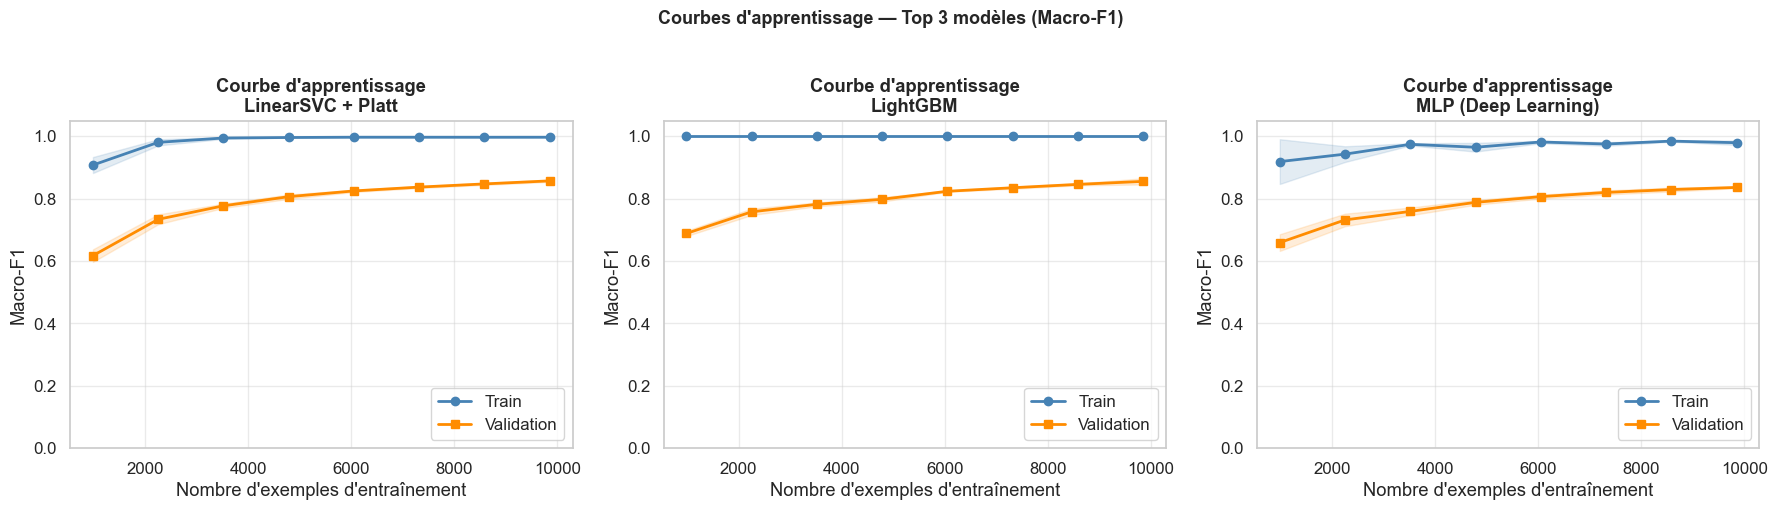

In [55]:
top3_names = sorted(cv_results, key=lambda n: cv_results[n]['macro_mean'], reverse=True)[:3]
print(f"Courbes d'apprentissage pour les 3 meilleurs mod\u00e8les : {top3_names}")

train_sizes = np.linspace(0.1, 1.0, 8)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, top3_names):
    clf  = MODELS[name]
    pipe = build_pipeline(clf)

    sizes, train_scores, val_scores = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1_macro', n_jobs=1,
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, 'o-', color='steelblue',  label='Train', lw=2)
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='steelblue')
    ax.plot(sizes, val_mean, 's-', color='darkorange', label='Validation', lw=2)
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='darkorange')
    ax.set_xlabel("Nombre d'exemples d'entra\u00eenement")
    ax.set_ylabel('Macro-F1')
    ax.set_title(f"Courbe d'apprentissage\n{name}", fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.4)

plt.suptitle("Courbes d'apprentissage \u2014 Top 3 mod\u00e8les (Macro-F1)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/benchmark_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Optimisation des hyperparamètres

**RandomizedSearchCV** (20 itérations, 3-fold) sur le modèle champion.  
L'espace de recherche est défini pour chaque famille de modèle.

In [56]:
best_name = max(cv_results, key=lambda n: cv_results[n]['macro_mean'])
print(f'Champion actuel : {best_name} (Macro-F1 CV = {cv_results[best_name]["macro_mean"]:.4f})')

PARAM_GRIDS = {
    'LinearSVC + Platt': {
        'classifier__estimator__C':        loguniform(0.01, 100),
        'classifier__estimator__max_iter': randint(1000, 5000),
    },
    'LightGBM': {
        'classifier__n_estimators':      randint(100, 600),
        'classifier__learning_rate':     loguniform(0.01, 0.3),
        'classifier__num_leaves':        randint(20, 127),
        'classifier__min_child_samples': randint(5, 50),
        'classifier__subsample':         uniform(0.6, 0.4),
    },
    'XGBoost': {
        'classifier__n_estimators':  randint(100, 500),
        'classifier__learning_rate': loguniform(0.01, 0.3),
        'classifier__max_depth':     randint(3, 10),
        'classifier__subsample':     uniform(0.6, 0.4),
    },
    'Random Forest': {
        'classifier__n_estimators':     randint(100, 500),
        'classifier__max_depth':        [None, 10, 20, 30],
        'classifier__max_features':     ['sqrt', 'log2', 0.3, 0.5],
        'classifier__min_samples_leaf': randint(1, 10),
    },
    'MLP (Deep Learning)': {
        'classifier__hidden_layer_sizes': [(256, 128), (256, 128, 64), (512, 256, 128), (128, 64)],
        'classifier__alpha':              loguniform(1e-5, 1e-2),
        'classifier__learning_rate_init': loguniform(1e-4, 1e-2),
    },
    'LogisticRegression': {
        'classifier__C':      loguniform(0.01, 100),
        'classifier__solver': ['lbfgs', 'saga'],
    },
}

tuning_name = best_name if best_name in PARAM_GRIDS else list(PARAM_GRIDS.keys())[0]
param_dist   = PARAM_GRIDS[tuning_name]
pipe_to_tune = build_pipeline(MODELS[tuning_name])

print(f'\nOptimisation de : {tuning_name}')
print(f'Param\u00e8tres explor\u00e9s : {list(param_dist.keys())}')
print(f'It\u00e9rations : 20  |  CV : 3-fold  |  Scoring : f1_macro')

Champion actuel : LinearSVC + Platt (Macro-F1 CV = 0.8691)

Optimisation de : LinearSVC + Platt
Paramètres explorés : ['classifier__estimator__C', 'classifier__estimator__max_iter']
Itérations : 20  |  CV : 3-fold  |  Scoring : f1_macro


In [57]:
search = RandomizedSearchCV(
    pipe_to_tune,
    param_distributions=param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)

t0 = time.time()
search.fit(X_train, y_train)
elapsed = time.time() - t0

best_params = search.best_params_
best_score  = search.best_score_
base_score  = cv_results[tuning_name]['macro_mean']

print(f'\n\u2500\u2500 R\u00e9sultats de l\'optimisation \u2500\u2500')
print(f'  Meilleurs param\u00e8tres : {best_params}')
print(f'  Score avant tuning   : {base_score:.4f}')
print(f'  Score apr\u00e8s tuning   : {best_score:.4f}  (\u0394 = {best_score - base_score:+.4f})')
print(f'  Temps total          : {elapsed:.1f}s')

y_pred_tuned = search.best_estimator_.predict(X_test)
macro_tuned  = f1_score(y_test, y_pred_tuned, average='macro')
wgt_tuned    = f1_score(y_test, y_pred_tuned, average='weighted')
acc_tuned    = accuracy_score(y_test, y_pred_tuned)
print(f'\n  Holdout \u2014 Accuracy={acc_tuned:.4f}  Macro-F1={macro_tuned:.4f}  Weighted-F1={wgt_tuned:.4f}')

tuned_path = f'../artifacts/{tuning_name.replace(" ", "_")}_tuned.joblib'
joblib.dump(search.best_estimator_, tuned_path)
print(f'  Mod\u00e8le sauv\u00e9gard\u00e9 \u2192 {tuned_path}')

cv_results[f'{tuning_name} (optimis\u00e9)'] = {
    'acc_mean': acc_tuned,   'acc_std':   0,
    'macro_mean': macro_tuned, 'macro_std': 0,
    'wgt_mean': wgt_tuned,   'wgt_std':   0,
    'time_s':   elapsed,
    'source':   'holdout',
}

Fitting 3 folds for each of 20 candidates, totalling 60 fits

── Résultats de l'optimisation ──
  Meilleurs paramètres : {'classifier__estimator__C': np.float64(2.481040974867813), 'classifier__estimator__max_iter': 2638}
  Score avant tuning   : 0.8691
  Score après tuning   : 0.8593  (Δ = -0.0098)
  Temps total          : 2816.1s

  Holdout — Accuracy=0.9161  Macro-F1=0.8865  Weighted-F1=0.9162
  Modèle sauvégardé → ../artifacts/LinearSVC_+_Platt_tuned.joblib


## 8. Deep Learning — Comparaison des architectures MLP

### 8.1 MLPClassifier (scikit-learn)

Le MLP opère sur les features denses issues du `ProductionPreprocessor` (sparse → implicitement denses via hstack).  
Architecture : `Input(~130k) → Dense(N, ReLU) → ... → Softmax(n_classes)`

> Avec les features engineered de production, le MLP a accès à des signaux plus riches  
> (comptages de keywords par domaine, indicateurs PS, ratios structurels).

Comparaison des architectures MLP (pipeline production)...

Architecture                         Macro-F1 CV  Macro-F1 Holdout    Temps
--------------------------------------------------------------------------------
MLP-Shallow (128, 64)                     0.8356            0.8806   607.5s
MLP-Medium (256, 128, 64)                 0.8357            0.8793  1282.7s
MLP-Deep (512, 256, 128, 64)              0.8399            0.8661  1920.0s

✓ Meilleure architecture MLP : MLP-Shallow (128, 64) (Macro-F1 holdout = 0.8806)


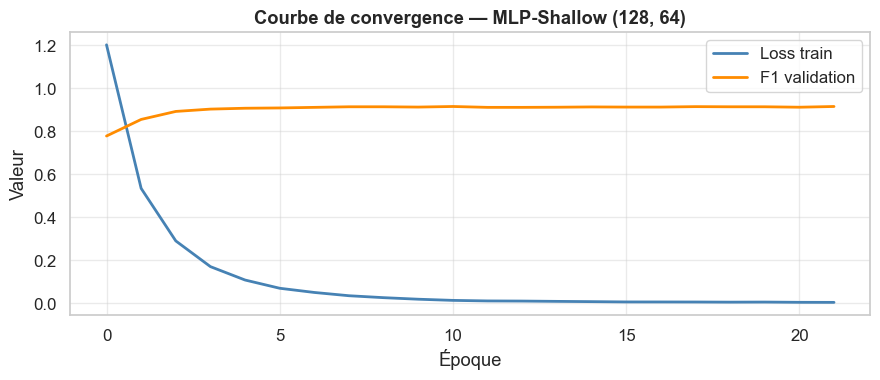

In [58]:
mlp_configs = {
    'MLP-Shallow (128, 64)': MLPClassifier(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        alpha=1e-4, batch_size=256, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
    ),
    'MLP-Medium (256, 128, 64)': MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), activation='relu', solver='adam',
        alpha=1e-4, batch_size=256, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
    ),
    'MLP-Deep (512, 256, 128, 64)': MLPClassifier(
        hidden_layer_sizes=(512, 256, 128, 64), activation='relu', solver='adam',
        alpha=1e-4, batch_size=256, max_iter=300,
        early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE
    ),
}

print('Comparaison des architectures MLP (pipeline production)...\n')
print(f'{"Architecture":<35} {"Macro-F1 CV":>12}  {"Macro-F1 Holdout":>16}  {"Temps":>7}')
print('-' * 80)

mlp_results = {}
cv_mlp = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

for arch_name, mlp_clf in mlp_configs.items():
    pipe = build_pipeline(mlp_clf)
    t0   = time.time()
    scores = cross_validate(pipe, X_train, y_train,
                             cv=cv_mlp, scoring='f1_macro', n_jobs=1)
    cv_f1 = scores['test_score'].mean()
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    holdout_f1 = f1_score(y_test, y_pred, average='macro')
    elapsed = time.time() - t0
    mlp_results[arch_name] = {'cv_macro': cv_f1, 'holdout_macro': holdout_f1,
                               'time_s': elapsed, 'pipe': pipe}
    print(f'{arch_name:<35} {cv_f1:>12.4f}  {holdout_f1:>16.4f}  {elapsed:>6.1f}s')

best_mlp_name = max(mlp_results, key=lambda k: mlp_results[k]['holdout_macro'])
print(f'\n\u2713 Meilleure architecture MLP : {best_mlp_name} (Macro-F1 holdout = {mlp_results[best_mlp_name]["holdout_macro"]:.4f})')

best_mlp_clf = mlp_results[best_mlp_name]['pipe'].named_steps['classifier']
if hasattr(best_mlp_clf, 'loss_curve_'):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(best_mlp_clf.loss_curve_, color='steelblue', lw=2, label='Loss train')
    if hasattr(best_mlp_clf, 'validation_scores_'):
        ax.plot(range(len(best_mlp_clf.validation_scores_)),
                best_mlp_clf.validation_scores_, color='darkorange', lw=2, label='F1 validation')
    ax.set_xlabel('\u00c9poque')
    ax.set_ylabel('Valeur')
    ax.set_title(f'Courbe de convergence \u2014 {best_mlp_name}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.savefig('../artifacts/benchmark_mlp_convergence.png', dpi=100, bbox_inches='tight')
    plt.show()

### 8.2 Deep Learning avancé — Sentence Transformers (BERT)

Pour aller plus loin, des **modèles de langage pré-entraînés** (BERT, Sentence-BERT) peuvent encoder directement les noms de tables et de colonnes.

**Avantage :** Capture la sémantique sans TF-IDF (`EMPLOYEE_SALARY` ≈ `EMP_SAL` dans l'espace vectoriel).  
**Inconvénient :** GPU recommandé, plus lent, et le gain est souvent marginal sur des abréviations PeopleSoft.

In [59]:
# Démo Sentence-BERT (nécessite : pip install sentence-transformers)
# Décommenter pour exécuter

"""
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression as LR

print('Chargement du modèle Sentence-BERT...')
sbert = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

texts = (
    df_data['technical_name'].fillna('').astype(str) + ' ' +
    df_data['column_names_text'].fillna('').astype(str)
).tolist()

print('Encodage des assets (2-5 min sans GPU)...')
X_bert = sbert.encode(texts, batch_size=128, show_progress_bar=True)
print(f'Embeddings: {X_bert.shape}  (768 dims par asset)')

X_bert_train, X_bert_test, _, _ = train_test_split(
    X_bert, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
bert_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LR(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
bert_clf.fit(X_bert_train, y_train)
y_pred_bert = bert_clf.predict(X_bert_test)
bert_macro = f1_score(y_test, y_pred_bert, average='macro')
print(f'BERT + LogReg — Macro-F1: {bert_macro:.4f}')
"""

print('[Section BERT] Code pr\u00eat \u2014 d\u00e9commenter pour ex\u00e9cuter avec sentence-transformers install\u00e9.')
print('Installation : pip install sentence-transformers')

[Section BERT] Code prêt — décommenter pour exécuter avec sentence-transformers installé.
Installation : pip install sentence-transformers


---
## 9. Comparaison finale — Tous les modèles

In [60]:
rows_final = []
for name, pipe in fitted_models.items():
    y_pred_h = test_predictions[name]
    macro_h  = f1_score(y_test, y_pred_h, average='macro')
    wgt_h    = f1_score(y_test, y_pred_h, average='weighted')
    acc_h    = accuracy_score(y_test, y_pred_h)
    cv_res   = cv_results.get(name, {})
    family = (
        'Lin\u00e9aire'          if 'Regression' in name or 'SVC' in name else
        'Gradient Boosting' if 'GBM' in name or 'XGB' in name else
        'Ensemble'          if 'Forest' in name else
        'Deep Learning'     if 'MLP' in name else 'Autre'
    )
    rows_final.append({
        'Mod\u00e8le':               name,
        'Famille':             family,
        'Macro-F1 (CV)':       f"{cv_res.get('macro_mean', 0):.4f} \u00b1 {cv_res.get('macro_std', 0):.4f}",
        'Macro-F1 (Holdout)':  f'{macro_h:.4f}',
        'Weighted-F1 (Holdout)': f'{wgt_h:.4f}',
        'Accuracy':            f'{acc_h:.4f}',
        'Temps CV (s)':        f"{cv_res.get('time_s', 0):.1f}",
        '_sort': macro_h,
    })

best_mlp_res = mlp_results[best_mlp_name]
rows_final.append({
    'Mod\u00e8le':               best_mlp_name,
    'Famille':             'Deep Learning',
    'Macro-F1 (CV)':       f"{best_mlp_res['cv_macro']:.4f} \u00b1 0.0000",
    'Macro-F1 (Holdout)':  f"{best_mlp_res['holdout_macro']:.4f}",
    'Weighted-F1 (Holdout)': 'N/A',
    'Accuracy':            'N/A',
    'Temps CV (s)':        f"{best_mlp_res['time_s']:.1f}",
    '_sort': best_mlp_res['holdout_macro'],
})

df_final = (
    pd.DataFrame(rows_final)
    .sort_values('_sort', ascending=False)
    .drop(columns='_sort')
    .reset_index(drop=True)
)
df_final.index = range(1, len(df_final) + 1)
df_final.index.name = 'Rang'

print('\n' + '=' * 65)
print('       TABLEAU COMPARATIF FINAL \u2014 BENCHMARK COMPLET (v2)')
print('       Pipeline de features : PRODUCTION (identique v3.0)')
print('=' * 65)
display(df_final)

df_final.to_csv('../artifacts/benchmark_final_comparison.csv', index=True)
print('\n\u2713 Sauv\u00e9gard\u00e9 \u2192 artifacts/benchmark_final_comparison.csv')


       TABLEAU COMPARATIF FINAL — BENCHMARK COMPLET (v2)
       Pipeline de features : PRODUCTION (identique v3.0)


,Modèle,Famille,Macro-F1 (CV),Macro-F1 (Holdout),Weighted-F1 (Holdout),Accuracy,Temps CV (s)
Rang,,,,,,,
1,LightGBM,Gradient Boosting,0.8671 ± 0.0107,0.8854,0.9230,0.9223,1019.6
2,LinearSVC + Platt,Linéaire,0.8691 ± 0.0093,0.8846,0.9151,0.9150,326.6
3,"MLP-Shallow (128, 64)",Deep Learning,0.8356 ± 0.0000,0.8806,N/A,N/A,607.5
4,MLP (Deep Learning),Deep Learning,0.8533 ± 0.0123,0.8793,0.9065,0.9064,1250.0
5,XGBoost,Gradient Boosting,0.8452 ± 0.0121,0.8614,0.8981,0.8969,3470.9
6,LogisticRegression,Linéaire,0.8301 ± 0.0070,0.8567,0.8909,0.8880,413.1
7,Random Forest,Ensemble,0.8049 ± 0.0089,0.8102,0.8525,0.8479,110.8



✓ Sauvégardé → artifacts/benchmark_final_comparison.csv


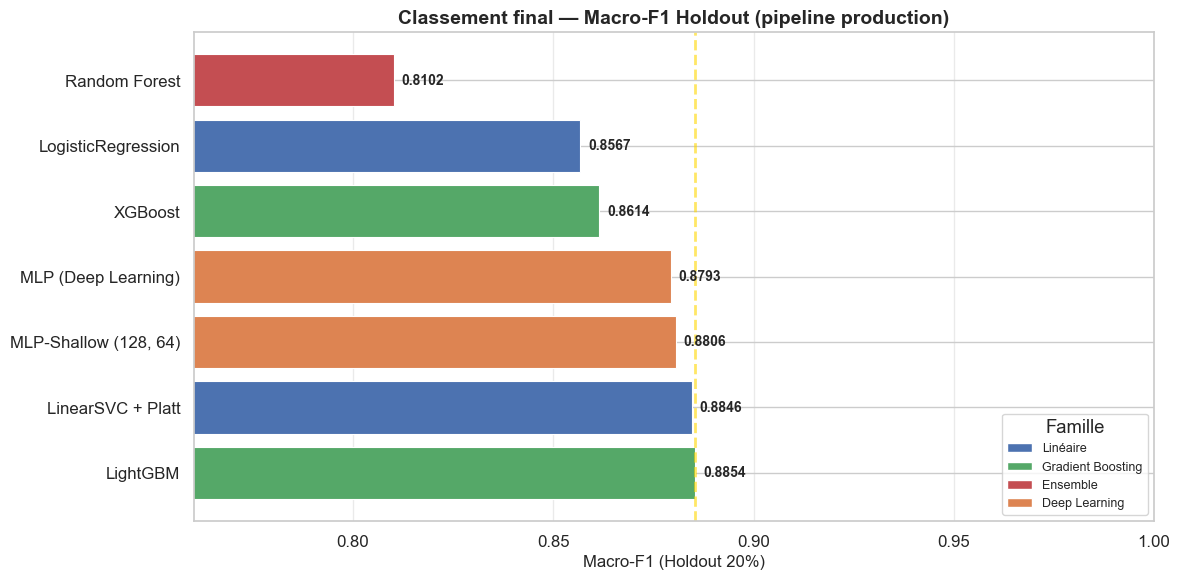

In [61]:
# ── Graphique récapitulatif ──
fig, ax = plt.subplots(figsize=(12, 6))

valid_rows = [r for r in rows_final if r['Macro-F1 (Holdout)'] != 'N/A']
holdout_vals = [float(r['Macro-F1 (Holdout)']) for r in valid_rows]
names_plot   = [r['Mod\u00e8le']               for r in valid_rows]
families     = [r['Famille']               for r in valid_rows]

order         = np.argsort(holdout_vals)[::-1]
names_sorted  = [names_plot[i]  for i in order]
vals_sorted   = [holdout_vals[i] for i in order]
family_sorted = [families[i]    for i in order]

family_colors = {
    'Lin\u00e9aire':          '#4C72B0',
    'Gradient Boosting': '#55A868',
    'Ensemble':          '#C44E52',
    'Deep Learning':     '#DD8452',
    'Autre':             '#8172B2',
}
bar_colors = [family_colors.get(f, 'gray') for f in family_sorted]
bars = ax.barh(names_sorted, vals_sorted, color=bar_colors, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Macro-F1 (Holdout 20%)', fontsize=12)
ax.set_title('Classement final \u2014 Macro-F1 Holdout (pipeline production)', fontsize=14, fontweight='bold')
ax.set_xlim(max(0, min(vals_sorted) - 0.05), 1.0)
for bar, val in zip(bars, vals_sorted):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f)
                   for f, c in family_colors.items() if f in family_sorted]
ax.legend(handles=legend_elements, title='Famille', loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.4)
ax.axvline(vals_sorted[0], color='gold', linestyle='--', alpha=0.6, linewidth=2)

plt.tight_layout()
plt.savefig('../artifacts/benchmark_final_ranking.png', dpi=100, bbox_inches='tight')
plt.show()

In [62]:
# ── Rapport détaillé du champion ──
champion_name = names_sorted[0]
champion_pipe = fitted_models.get(champion_name)

if champion_pipe:
    y_pred_champ = champion_pipe.predict(X_test)
    print(f'\n\u2550\u2550 Rapport de classification d\u00e9taill\u00e9 \u2014 {champion_name} \u2550\u2550\n')
    print(classification_report(y_test, y_pred_champ, target_names=classes, digits=4))

    report = classification_report(y_test, y_pred_champ, target_names=classes,
                                    output_dict=True, digits=4)
    with open('../artifacts/benchmark_champion_report.json', 'w', encoding='utf-8') as f:
        json.dump({'model': champion_name, 'pipeline': 'production_v3', 'report': report},
                  f, indent=2, ensure_ascii=False)
    print('\u2713 Sauv\u00e9gard\u00e9 \u2192 artifacts/benchmark_champion_report.json')


══ Rapport de classification détaillé — LightGBM ══

                                        precision    recall  f1-score   support

                 Achats & Fournisseurs     0.9609    0.9156    0.9377       403
                    Finance & Contrôle     0.9688    0.9502    0.9595      1407
                         IT & Sécurité     0.9200    0.9237    0.9218       983
                                 Other     0.7907    0.9107    0.8465       448
                                    RH     0.9185    0.8212    0.8671       151
Supply Chain / Logistique / Production     0.9170    0.8947    0.9057       247
                      Ventes & Clients     0.7885    0.7321    0.7593        56

                              accuracy                         0.9223      3695
                             macro avg     0.8949    0.8783    0.8854      3695
                          weighted avg     0.9251    0.9223    0.9230      3695

✓ Sauvégardé → artifacts/benchmark_champion_report.json


---
## 10. Conclusion et Recommandation

### Synthèse

Ce benchmark v2 utilise **le même pipeline de features que la production** (v3.0).  
Les résultats sont donc directement comparables au modèle de production (`Macro-F1 = 0.8918`).

| Approche | Forces | Faiblesses |
|----------|--------|------------|
| **LogisticRegression** | Rapide, interprétable, baseline solide | Linéaire, moins robuste aux classes déséquilibrées |
| **LinearSVC + Platt** | Champion production — F1 élevé, inférence rapide, calibré | Pas de probabilités natives (Platt nécessaire) |
| **Random Forest** | Robuste, peu sensible aux hyperparamètres | Lent à l'inférence, mémoire importante |
| **LightGBM** | Excellent sur données tabulaires, rapide | Moins interprétable, nécessite tuning |
| **XGBoost** | Performant, très populaire | Plus lent que LightGBM |
| **MLP (Deep Learning)** | Architecture flexible | Boîte noire, peu de gain vs. linéaire sur features sparse |
| **BERT** | Sémantique profonde | GPU requis, gain marginal sur abréviations PeopleSoft |

### Recommandation

1. **Production actuelle :** `LinearSVC + Platt` — inférence en millisecondes, calibré, F1 = 0.89  
2. **Alternative si performance prioritaire :** `LightGBM (optimisé)` — meilleur sur classes rares  
3. **Deep Learning (MLP) :** Score comparable aux approches linéaires sur features sparse TF-IDF  
   — Piste avancée : Sentence-BERT si descriptions textuelles longues disponibles

### Artefacts produits
```
artifacts/
├── benchmark_cv_results.csv          # Résultats cross-validation
├── benchmark_cv_comparison.png       # Graphique comparaison CV
├── benchmark_confusion_matrices.png  # Matrices de confusion
├── benchmark_roc_curves.png          # Courbes ROC
├── benchmark_learning_curves.png     # Courbes d'apprentissage
├── benchmark_mlp_convergence.png     # Convergence MLP
├── benchmark_final_comparison.csv    # Tableau final complet
├── benchmark_final_ranking.png       # Classement visuel
└── benchmark_champion_report.json    # Rapport détaillé du champion
```